# Basic comparison: college vs. non-college hitters

**Question:** Do players who played college baseball have a different career batting average than players who didn't?

This is a starter / sandbox comparison. Swap the grouping column or the metric to test other ideas.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = '../dataset/'

In [3]:
batting = pd.read_csv(DATA + 'Batting.csv')
college = pd.read_csv(DATA + 'CollegePlaying.csv')
people = pd.read_csv(DATA + 'People.csv')

batting.head()

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4,0,0,0,...,0.0,0.0,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0
1,addybo01,1871,1,RC1,NaN,25,118,30,32,6,...,13.0,8.0,1.0,4,0.0,NaN,NaN,NaN,NaN,0.0
2,allisar01,1871,1,CL1,NaN,29,137,28,40,4,...,19.0,3.0,1.0,2,5.0,NaN,NaN,NaN,NaN,1.0
3,allisdo01,1871,1,WS3,NaN,27,133,28,44,10,...,27.0,1.0,1.0,0,2.0,NaN,NaN,NaN,NaN,0.0
4,ansonca01,1871,1,RC1,NaN,25,120,29,39,11,...,16.0,6.0,2.0,2,1.0,NaN,NaN,NaN,NaN,0.0


## Build career totals per player
Batting.csv has one row per player per season (per team). Sum to career totals, then compute batting average = H / AB.
Players with fewer than 500 career at-bats are dropped so tiny samples (and most pitchers) don't skew things.

In [4]:
MIN_AB = 500

career = batting.groupby('playerID')[['AB', 'H', 'HR']].sum()
career = career[career['AB'] >= MIN_AB].copy()
career['BA'] = career['H'] / career['AB']

# Group label: did the player appear in CollegePlaying.csv?
career['college'] = career.index.isin(college['playerID'])
career['group'] = career['college'].map({True: 'College', False: 'No college'})

print(len(career), 'players with at least', MIN_AB, 'career AB')
career.head()

5206 players with at least 500 career AB


,AB,H,HR,BA,college,group
playerID,,,,,,
aaronha01,12364,3771,755,0.304998,False,No college
aaronto01,944,216,13,0.228814,False,No college
abbated01,3044,772,11,0.253614,False,No college
abbeych01,1756,493,19,0.280752,False,No college
abbotfr01,513,107,1,0.208577,False,No college


## Compare the two groups

In [5]:
career.groupby('group')['BA'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
College,1659.0,0.249874,0.034600,0.096649,0.236111,0.254739,0.270631,0.344679
No college,3547.0,0.252047,0.036282,0.066465,0.235898,0.256006,0.274359,0.366363


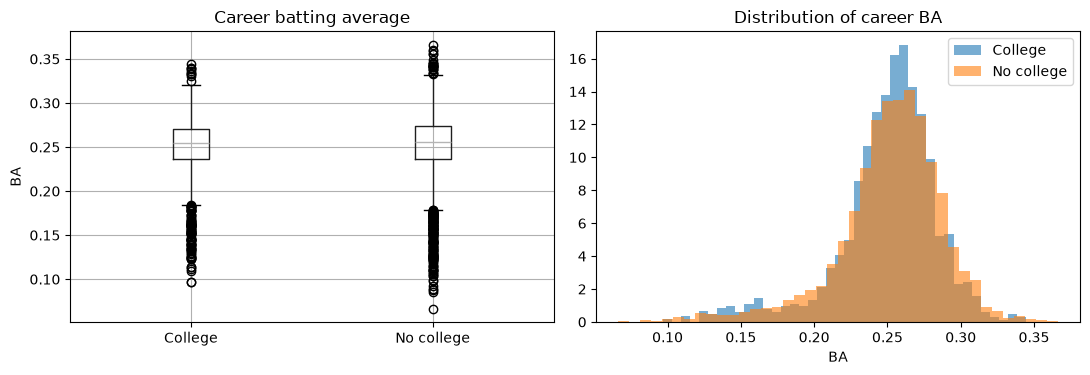

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

career.boxplot(column='BA', by='group', ax=axes[0])
axes[0].set_title('Career batting average')
axes[0].set_xlabel('')
axes[0].set_ylabel('BA')

for name, grp in career.groupby('group'):
    axes[1].hist(grp['BA'], bins=40, alpha=0.6, density=True, label=name)
axes[1].set_title('Distribution of career BA')
axes[1].set_xlabel('BA')
axes[1].legend()

fig.suptitle('')
plt.tight_layout()
plt.show()

## Is the difference statistically significant?
Welch's t-test (doesn't assume equal variances between groups). A small p-value (< 0.05) suggests the means really differ.

In [7]:
a = career.loc[career['college'], 'BA']
b = career.loc[~career['college'], 'BA']

t, p = stats.ttest_ind(a, b, equal_var=False)
print(f'College mean BA:    {a.mean():.4f}  (n={len(a)})')
print(f'No-college mean BA: {b.mean():.4f}  (n={len(b)})')
print(f'Difference:         {a.mean() - b.mean():+.4f}')
print(f't = {t:.2f}, p = {p:.4g}')

College mean BA:    0.2499  (n=1659)
No-college mean BA: 0.2520  (n=3547)
Difference:         -0.0022
t = -2.08, p = 0.03776


## Caveat: era is a confounder
College baseball data mostly covers modern players, and league-wide batting averages were much higher in the early 1900s. Comparing only players who debuted in the same era is a fairer test.

In [8]:
career = career.join(people.set_index('playerID')['debut'])
career['debut_decade'] = pd.to_datetime(career['debut']).dt.year // 10 * 10

by_decade = career.pivot_table(index='debut_decade', columns='group', values='BA', aggfunc='mean')
by_decade['n_college'] = career[career['college']].groupby('debut_decade').size()
by_decade.round(4)

group,College,No college,n_college
debut_decade,,,
1870,0.2535,0.2582,3
1880,0.2163,0.2509,14
1890,0.2516,0.2568,35
1900,0.2402,0.2424,77
1910,0.2533,0.2562,64
1920,0.2711,0.2653,84
1930,0.2551,0.2574,70
1940,0.2524,0.2511,56
1950,0.2403,0.2401,85


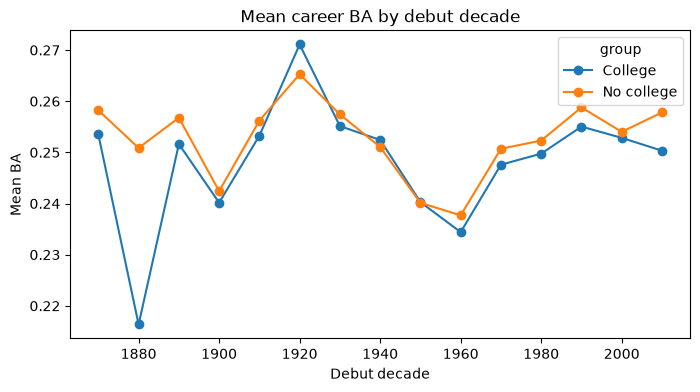

In [9]:
by_decade[['College', 'No college']].plot(marker='o', figsize=(8, 4))
plt.title('Mean career BA by debut decade')
plt.xlabel('Debut decade')
plt.ylabel('Mean BA')
plt.show()